Pip install the python packages if required  
Select conda env to be `london-bikes-env`

In [6]:
!pip install --upgrade SQLAlchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 5.2 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: SQLAlchemy
    Found existing installation: SQLAlchemy 2.0.43
    Uninstalling SQLAlchemy-2.0.43:
      Successfully uninstalled SQLAlchemy-2.0.43


In [8]:
!pip install sqlalchemy-bigquery

In [11]:
!pip install geopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]


In [ ]:
# Run this cell 1st

from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import folium
from folium import plugins
import numpy as np

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


# Replace 'your-project-id' with your actual Google Cloud project ID
project_id = 'your-project-id'
engine = create_engine(f'bigquery://{project_id}')

# Initialize geolocator
geolocator = Nominatim(user_agent="my_unique_geocoder_app")

# Set up RateLimiter
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)


In [7]:
# show the total rentals over time

query = text("""
SELECT
-- Select columns from both tables as needed
    COUNT(FH.rental_id) AS total_rentals,
    DD.day_of_week AS day_of_week,
    DD.day_type AS day_type,    
    DD.month AS month,
    DD.quarter AS quarter,
    DD.year AS year
FROM 
    london_bicycles_star.fact_hire AS FH
INNER JOIN 
    london_bicycles_star.dim_date AS DD ON FH.start_date_key = DD.date_key -- Join using the surrogate keys
GROUP BY
    year, quarter, month, day_type, day_of_week 
ORDER BY
    year, quarter, month, day_of_week
""")

df = pd.read_sql(query, engine)


In [8]:
df

,total_rentals,day_of_week,day_type,month,quarter,year
0,83315,1,Weekday,1,1,2015
1,93556,2,Weekday,1,1,2015
2,90214,3,Weekday,1,1,2015
3,83122,4,Weekday,1,1,2015
4,87830,5,Weekday,1,1,2015
...,...,...,...,...,...,...
674,39541,3,Weekday,1,1,2023
675,40362,4,Weekday,1,1,2023
676,39669,5,Weekday,1,1,2023
677,26254,6,Weekend,1,1,2023


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   total_rentals  679 non-null    int64 
 1   day_of_week    679 non-null    object
 2   day_type       679 non-null    object
 3   month          679 non-null    object
 4   quarter        679 non-null    object
 5   year           679 non-null    object
dtypes: int64(1), object(5)
memory usage: 32.0+ KB


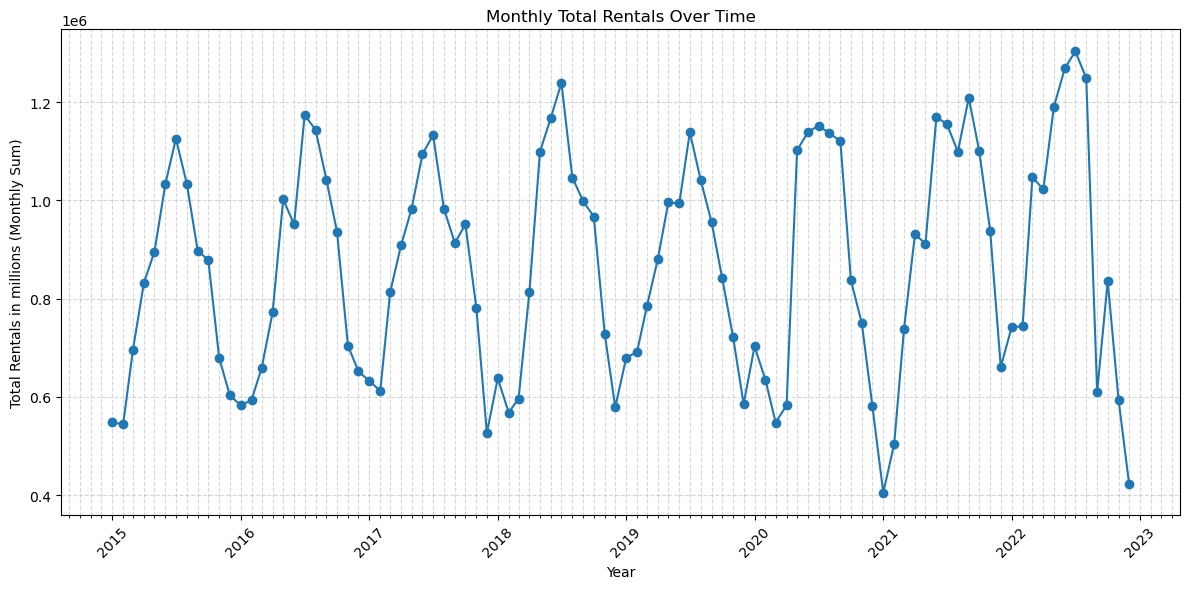

In [ ]:
# 1. Create a datetime column to ensure correct chronological sorting
df['date_temp'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))

# 2. Group by the date and sum the rentals
# We use 'date_temp' as the grouping key so the result is already in order
df_monthly = df.groupby('date_temp')['total_rentals'].sum().reset_index()

## Revision 16/3: drop the last month data '2023-01' due to data ending on 15/1/2023
df_monthly = df_monthly[:-1]

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_monthly['date_temp'], df_monthly['total_rentals'], marker='o')

# Set major ticks to Years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Set minor ticks to Months
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Standard formatting
plt.title('Monthly Total Rentals Over Time')
plt.xlabel('Year')
plt.ylabel('Total Rentals in millions (Monthly Sum)')
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
df_monthly.tail()

,date_temp,total_rentals
91,2022-08-01,1249038
92,2022-09-01,609978
93,2022-10-01,835240
94,2022-11-01,593444
95,2022-12-01,421860


**Background Info:** Bike hires are influence by the seasonal weather, peaking around the middle of the year and dipping at the start/end of the year.

Split the analysis between Winter and non-winter months

In [17]:
# Convert 'month' to integer and check if it's in the winter months (November to February)
df['Winter'] = df['month'].astype(int).isin([1, 2, 11, 12])


In [18]:
df

,total_rentals,day_of_week,day_type,month,quarter,year,date_temp,Winter
0,83315,1,Weekday,1,1,2015,2015-01-01,True
1,93556,2,Weekday,1,1,2015,2015-01-01,True
2,90214,3,Weekday,1,1,2015,2015-01-01,True
3,83122,4,Weekday,1,1,2015,2015-01-01,True
4,87830,5,Weekday,1,1,2015,2015-01-01,True
...,...,...,...,...,...,...,...,...
674,39541,3,Weekday,1,1,2023,2023-01-01,True
675,40362,4,Weekday,1,1,2023,2023-01-01,True
676,39669,5,Weekday,1,1,2023,2023-01-01,True
677,26254,6,Weekend,1,1,2023,2023-01-01,True


In [19]:
# Group the data to see the numeric trend
weekly_trend = df.groupby(['day_of_week', 'Winter'])['total_rentals'].mean().unstack()
print(weekly_trend)

Winter               False         True 
day_of_week                             
1            135183.468750  92751.363636
2            146263.359375  98686.666667
3            145278.484375  99967.121212
4            147586.359375  98014.696970
5            141985.875000  94402.181818
6            138531.312500  73455.939394
7            127558.703125  65814.363636


/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/tashrif/miniconda3/envs/london-bikes-env/lib/pytho

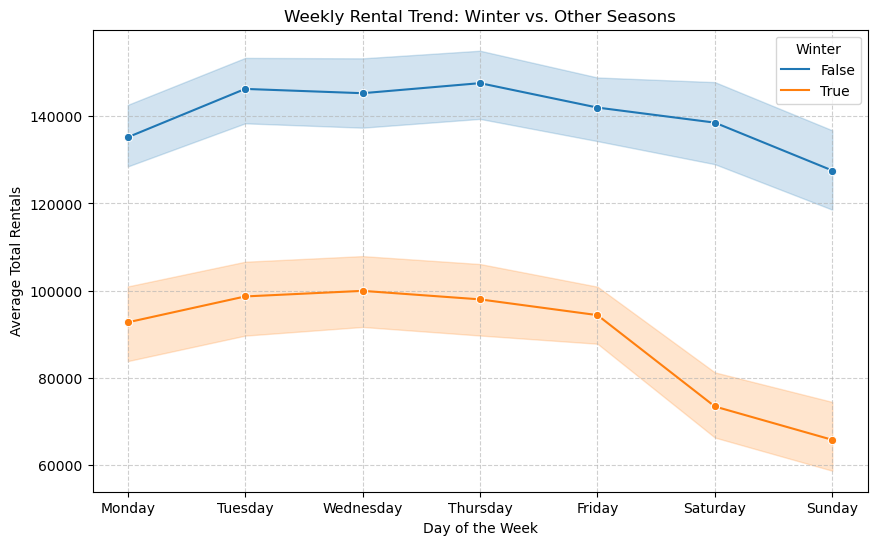

In [24]:
#import seaborn as sns
#import matplotlib.pyplot as plt

# Convert columns to numeric, forcing errors to NaN (just in case)
df['day_of_week'] = pd.to_numeric(df['day_of_week'], errors='coerce')

# Shift 1-7 range to 0-6 range
df['day_of_week'] = df['day_of_week'] - 1

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='day_of_week', y='total_rentals', hue='Winter', marker='o')

# Revision 16/3:
# Define the names and their corresponding numeric positions
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.xticks(ticks=range(7), labels=day_names)

plt.title('Weekly Rental Trend: Winter vs. Other Seasons')
plt.ylabel('Average Total Rentals')
plt.xlabel('Day of the Week')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight:**  During weekdays, averaging 140k bike hires per day in non-winter months, and dropping to slightly under 100k during winter months. During the winter weekends, there is a noticeable drop below 80k trips.

In [38]:
# show the total rentals over time

query = text("""
SELECT
    COUNT(FH.rental_id) AS total_rentals,           -- Column 1
    EXTRACT(MONTH FROM FH.start_date) AS month,     -- Column 2
    EXTRACT(DAYOFWEEK FROM FH.start_date) AS day_of_week, -- Column 3
    CASE 
        WHEN EXTRACT(DAYOFWEEK FROM FH.start_date) IN (1, 7) THEN 'Weekend'
        ELSE 'Weekday'
    END AS is_weekend,                              -- Column 4
    EXTRACT(HOUR FROM FH.start_date) AS hour,       -- Column 5
    EXTRACT(MINUTE FROM FH.start_date) AS minute    -- Column 6
FROM 
    london_bicycles_star.fact_hire AS FH
GROUP BY
    2, 3, 4, 5, 6
""")

df = pd.read_sql(query, engine)

In [39]:
df = df.sort_values(by=['hour', 'minute'], ascending=True)

In [40]:
# Convert 'month' to integer and check if it's in the winter months (November to February)
df['Winter'] = df['month'].astype(int).isin([1, 2, 11, 12])

In [41]:
df

,total_rentals,month,day_of_week,is_weekend,hour,minute,Winter
936,167,1,1,Weekend,0,0,True
4431,315,5,1,Weekend,0,0,False
4915,384,8,1,Weekend,0,0,False
6265,180,3,1,Weekend,0,0,False
6374,326,9,1,Weekend,0,0,False
...,...,...,...,...,...,...,...
113365,221,12,7,Weekend,23,59,True
113596,208,3,7,Weekend,23,59,False
114874,534,7,7,Weekend,23,59,False
116991,429,8,7,Weekend,23,59,False


/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tashrif/miniconda3/envs/london-bikes-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/tashrif/miniconda3/envs/london-bikes-env/lib/pytho

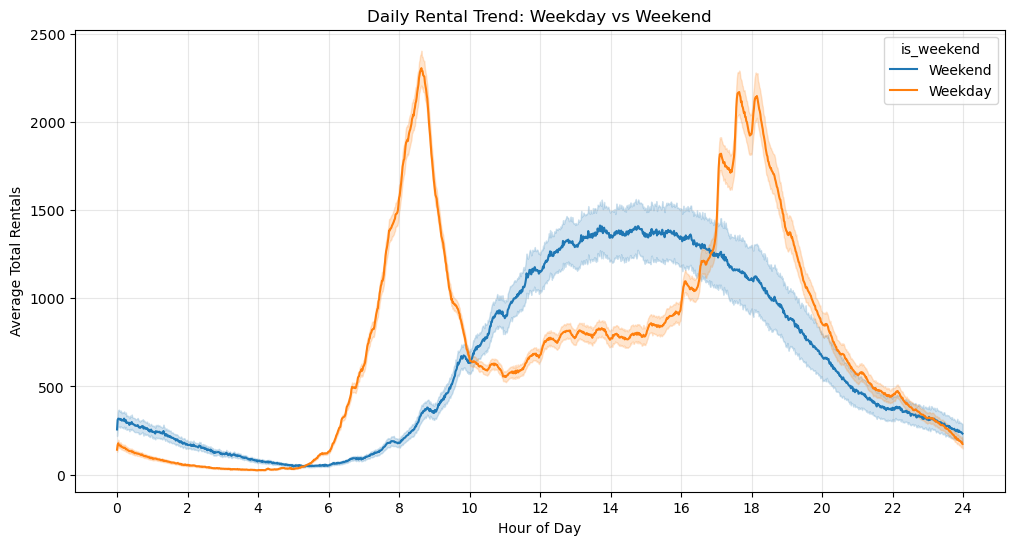

In [42]:
# 1. Create a continuous time feature (e.g., 1:30 PM becomes 13.5)
df['time_of_day'] = df['hour'] + (df['minute'] / 60)

# 2. Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='time_of_day', y='total_rentals', hue='is_weekend')

# 3. Format the X-axis
plt.title('Daily Rental Trend: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Total Rentals')
plt.xticks(range(0, 25, 2)) # Show ticks every 2 hours
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** Usage pattern vary between weekday and weekend. It can be observed that peak usage during weekdays correspond to the peak commuting hours. During the weekend, usage picks up in the afternoon.

In [21]:
# Get latest date in the fact table
query = text("""
SELECT
Max(date_value) AS max_date
FROM london_bicycles_star.fact_bike_daily_usage
""")

df = pd.read_sql(query, engine)

In [22]:
df

,max_date
0,2023-01-31


In [11]:
# take the max date 

query = text("""
SELECT
bike_id, daily_duration_minutes
FROM london_bicycles_star.fact_bike_daily_usage
WHERE date_value > '2023-01-01'
AND daily_duration_minutes > 0
""")

In [12]:
df = pd.read_sql(query, engine)

df

,bike_id,daily_duration_minutes
0,59156,103.0
1,59312,130.0
2,59320,81.0
3,58658,119.0
4,59384,75.0
...,...,...
81054,59349,71.0
81055,53542,71.0
81056,41113,71.0
81057,52286,71.0


In [3]:
# select bike_id, bike_model, total_duration_minutes from dim_bike and get the latest start_date in the fact_hire table

query = text("""
WITH RankedTrips AS (
  SELECT
    DB.bike_id,
    DB.bike_model,
    DB.total_duration_minutes,
    FH.end_station_id,
    FH.end_date AS lastUsed,
    -- Assign #1 to the most recent trip for each bike_id
    ROW_NUMBER() OVER(PARTITION BY DB.bike_id ORDER BY FH.end_date DESC) AS trip_rank
  FROM 
    `london_bicycles_star.fact_hire` AS FH
  INNER JOIN 
    `london_bicycles_star.dim_bike` AS DB ON FH.bike_id = DB.bike_id
)
SELECT 
  bike_id,
  bike_model,
  total_duration_minutes,
  end_station_id,
  lastUsed
FROM 
  RankedTrips
WHERE 
  trip_rank = 1; -- Only keep the absolute latest location        
""")

df = pd.read_sql(query, engine)

In [5]:
df

,bike_id,bike_model,total_duration_minutes,end_station_id,lastUsed
0,246,CLASSIC,124911.0,789,2022-08-12 10:50:00+00:00
1,318,CLASSIC,59718.0,495,2018-04-18 22:53:00+00:00
2,513,CLASSIC,157661.0,538,2022-09-06 16:35:00+00:00
3,542,CLASSIC,111453.0,553,2021-01-24 10:47:00+00:00
4,551,CLASSIC,41412.0,194,2017-10-13 10:04:00+00:00
...,...,...,...,...,...
31924,60211,PBSC_EBIKE,4876.0,1055,2023-01-15 17:29:00+00:00
31925,60233,PBSC_EBIKE,5417.0,1072,2023-01-15 17:47:00+00:00
31926,60300,PBSC_EBIKE,3825.0,982,2023-01-13 18:45:00+00:00
31927,60420,PBSC_EBIKE,5375.0,961,2023-01-15 14:55:00+00:00


In [6]:
# Subtract the fixed date (converted to datetime)
# This results in a timedelta object (days, hours, etc.)
# Strip the timezone info from the column before subtracting
# 2023-01-31 corresponds to max date in the dataset
df['UnusedDuration'] = pd.to_datetime('2023-01-31') - df['lastUsed'].dt.tz_localize(None)


In [7]:
df

,bike_id,bike_model,total_duration_minutes,end_station_id,lastUsed,UnusedDuration
0,246,CLASSIC,124911.0,789,2022-08-12 10:50:00+00:00,171 days 13:10:00
1,318,CLASSIC,59718.0,495,2018-04-18 22:53:00+00:00,1748 days 01:07:00
2,513,CLASSIC,157661.0,538,2022-09-06 16:35:00+00:00,146 days 07:25:00
3,542,CLASSIC,111453.0,553,2021-01-24 10:47:00+00:00,736 days 13:13:00
4,551,CLASSIC,41412.0,194,2017-10-13 10:04:00+00:00,1935 days 13:56:00
...,...,...,...,...,...,...
31924,60211,PBSC_EBIKE,4876.0,1055,2023-01-15 17:29:00+00:00,15 days 06:31:00
31925,60233,PBSC_EBIKE,5417.0,1072,2023-01-15 17:47:00+00:00,15 days 06:13:00
31926,60300,PBSC_EBIKE,3825.0,982,2023-01-13 18:45:00+00:00,17 days 05:15:00
31927,60420,PBSC_EBIKE,5375.0,961,2023-01-15 14:55:00+00:00,15 days 09:05:00


In [8]:
# Convert duration to total days as a float
df['Unused Days'] = df['UnusedDuration'].dt.total_seconds() / (24 * 3600)

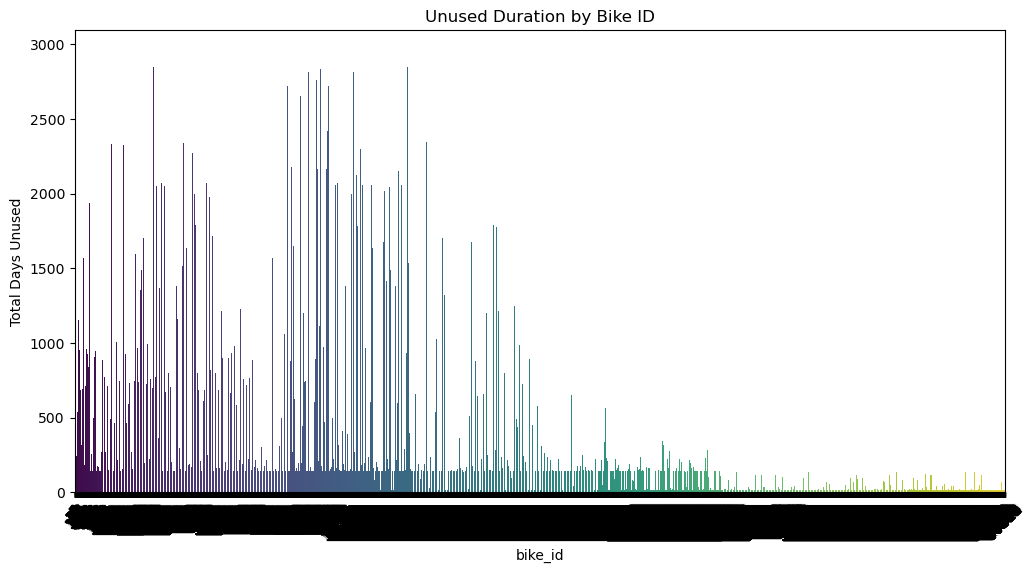

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='bike_id', y='Unused Days', palette='viridis')

plt.title('Unused Duration by Bike ID')
plt.xticks(rotation=45) # Rotates IDs if they are long or crowded
plt.ylabel('Total Days Unused')
plt.show()

# runtime about 2min plus

In [70]:
!pip install pandas folium

In [35]:
query = text("""
SELECT
*
FROM london_bicycles_star.dim_station
""")

df_dim_station = pd.read_sql(query, engine)

In [36]:
df_dim_station

,station_key,station_id,station_name,total_start_count,total_end_count
0,6302ada9052829b8d9cd3cc5804eb5c2,864,"Abbey Orchard Street, Westminster",342,877
1,45335e0a17654e889b0cddbf66f2f189,108,"Abbey Orchard Street, Westminster",117847,140640
2,47a122e73478bc6efcf67d95b05e3c22,3429,"Abbey Orchard Street, Westminster",3385,4004
3,fda6382348e6b3743704a98781769c69,559,"Abbotsbury Road, Holland Park",37095,34118
4,44fe97c2e632068aee07af6fdb324f42,200111,"Abbotsbury Road, Holland Park",1096,973
...,...,...,...,...,...
1824,58a17708d5757c6fe751abf76899ec49,0,"Parkway, Camden Town",0,8178
1825,2734db6c5a6151dd74451b2ad5f037ae,0,"Regent's Row , Haggerston",0,8178
1826,8fceb93364af70882d32496f5763b7dd,0,"Southwark Station 1, Southwark",0,8178
1827,5976fc557d655d9c8fa87d76842fae07,0,"Tavistock Street, Covent Garden",0,8178


In [45]:
df_cycle_stations = pd.read_csv('../data/warehouse/cycle_stations.csv')

In [46]:
df_cycle_stations

,id,installed,latitude,locked,longitude,name,bikes_count,docks_count,nbEmptyDocks,temporary,terminal_name,install_date,removal_date
0,126,True,51.517821,False,-0.096497,"Museum of London, Barbican",0,52,51,False,1043,2010-07-15,NaN
1,136,True,51.511962,False,-0.097442,"Queen Victoria Street, St. Paul's",0,32,30,False,1048,2010-07-15,NaN
2,140,True,51.520963,False,-0.085634,"Finsbury Square , Moorgate",0,33,33,False,1056,2010-07-15,NaN
3,215,True,51.519069,False,-0.088285,"Moorfields, Moorgate",0,54,54,False,1092,2010-07-19,NaN
4,266,True,51.501027,False,-0.180246,"Queen's Gate (North), Kensington",0,41,41,False,1204,2010-07-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,421,True,51.504044,False,-0.104778,"Southwark Station 2, Southwark",10,45,35,False,22163,2011-06-28,NaN
796,66,True,51.517950,False,-0.108657,"Holborn Circus, Holborn",0,40,40,False,982,2010-07-11,NaN
797,865,True,51.524696,False,-0.084439,"Leonard Circus , Shoreditch",0,43,40,False,1020,2010-07-07,NaN
798,80,True,51.500694,False,-0.102091,"Webber Street , Southwark",5,45,40,False,3448,2010-07-12,NaN


In [47]:
# 1. Create the Magnitude column in the dimension table
df_dim_station['Magnitude'] = df_dim_station['total_start_count'] + df_dim_station['total_end_count']

# 2. Merge only the necessary column into df_cycle_stations
df_cycle_stations = df_cycle_stations.merge(
    df_dim_station[['station_id', 'station_name', 'Magnitude']], 
    left_on=['id','name'], 
    right_on=['station_id','station_name'], 
    how='left'
).drop(columns=['station_id', 'station_name'])

In [50]:
# 2. Merge based on terminal_name
df_cycle_stations = df_cycle_stations.merge(
    df_dim_station[['station_id', 'station_name', 'Magnitude']], 
    left_on=['terminal_name', 'name'], 
    right_on=['station_id', 'station_name'],
    how='left'
).drop(columns=['station_id', 'station_name'])

In [59]:
df_cycle_stations

,id,installed,latitude,locked,longitude,name,bikes_count,docks_count,nbEmptyDocks,temporary,terminal_name,install_date,removal_date,Magnitude_x,Magnitude_y,Magnitude
0,126,True,51.517821,False,-0.096497,"Museum of London, Barbican",0,52,51,False,1043,2010-07-15,NaN,267681.0,7447.0,275128.0
1,136,True,51.511962,False,-0.097442,"Queen Victoria Street, St. Paul's",0,32,30,False,1048,2010-07-15,NaN,301718.0,6934.0,308652.0
2,140,True,51.520963,False,-0.085634,"Finsbury Square , Moorgate",0,33,33,False,1056,2010-07-15,NaN,256354.0,5607.0,261961.0
3,215,True,51.519069,False,-0.088285,"Moorfields, Moorgate",0,54,54,False,1092,2010-07-19,NaN,397435.0,11810.0,409245.0
4,266,True,51.501027,False,-0.180246,"Queen's Gate (North), Kensington",0,41,41,False,1204,2010-07-21,NaN,216291.0,7440.0,223731.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,421,True,51.504044,False,-0.104778,"Southwark Station 2, Southwark",10,45,35,False,22163,2011-06-28,NaN,236192.0,4755.0,240947.0
796,66,True,51.517950,False,-0.108657,"Holborn Circus, Holborn",0,40,40,False,982,2010-07-11,NaN,520691.0,13462.0,534153.0
797,865,True,51.524696,False,-0.084439,"Leonard Circus , Shoreditch",0,43,40,False,1020,2010-07-07,NaN,1753.0,9896.0,11649.0
798,80,True,51.500694,False,-0.102091,"Webber Street , Southwark",5,45,40,False,3448,2010-07-12,NaN,166207.0,6345.0,172552.0


In [66]:
df_cycle_stations[df_cycle_stations['Magnitude'].isna()]

,id,installed,latitude,locked,longitude,name,bikes_count,docks_count,nbEmptyDocks,temporary,terminal_name,install_date,removal_date,Magnitude_x,Magnitude_y,Magnitude


In [53]:
df_cycle_stations['Magnitude'] = df_cycle_stations['Magnitude_x'].add(df_cycle_stations['Magnitude_y'], fill_value=0)

In [65]:
#  All missing values (NaN/None) in the 'Magnitude' column of the df_cycle_stations DataFrame are replaced with the number 0
df_cycle_stations['Magnitude'] = df_cycle_stations['Magnitude'].fillna(0)

In [67]:
# Convert the DataFrame to the required list format
# If you don't have a magnitude/weight column, just use df[['Latitude', 'Longitude']].values.tolist()
heat_data = df_cycle_stations[['latitude', 'longitude', 'Magnitude']].values.tolist()

In [68]:
# check for any NaN values, if any, visualisation will fail.
pd.isna(heat_data).any()


False

If map doesn't display, need to uncheck Security > Workspace > Trust: Enabled setting and restart VS Code

In [69]:
# Define the starting location and zoom level
# Centered roughly in the middle of our sample UK cities
map_center = [51.5, -1.2] 
m = folium.Map(location=map_center, zoom_start=6)

# Add the heatmap layer
plugins.HeatMap(heat_data).add_to(m)

# Display the map in the Jupyter Notebook
m